# Métodos aproximados

En muchos problemas de aprendizaje por refuerzo el espacio de estados es demasiado grande
(o incluso continuo), por lo que los métodos tabulares que describimos en el notebook anterior dejan de ser prácticos.

En los métodos tabulares el agente aprendía directamente una tabla de valores:

\[
Q(s,a)
\]

donde para cada par estado–acción se almacenaba un valor estimado del retorno esperado.

Sin embargo, en entornos como **Acrobot-v1**, donde el estado está formado por variables continuas
(ángulos y velocidades angulares), el número de estados posibles es extremadamente grande.
En este tipo de problemas no resulta viable almacenar todos los valores en una tabla.

Para resolver esta limitación se utilizan **métodos de aproximación de funciones**.

La idea es aprender una función parametrizada que aproxime la función valor–acción:

$$
\hat{q}(s,a,w) \approx q_{\pi}(s,a)
$$

donde:

- \(s\) es el estado,
- \(a\) es la acción,
- \(w\) es el vector de parámetros del modelo.

De esta forma, el agente no memoriza valores para cada estado concreto,
sino que aprende un modelo capaz de **generalizar entre estados similares**.

En este notebook compararemos dos enfoques distintos de aproximación:

- **SARSA semi-gradiente con Tile Coding**
- **Deep Q-Learning (DQN) con redes neuronales**

Ambos métodos permiten aplicar aprendizaje por refuerzo en problemas con espacios de estados continuos o de gran dimensión.

In [24]:
# Importamos las librerías necesarias
from src.agents import AgentDeepQLearning, AgentSemiGradientSARSA
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from gymnasium.wrappers import RecordVideo
from pathlib import Path
from IPython.display import Video, display


# Fijamos la semilla para reproducibilidad del experimento
seed = 42
np.random.seed(seed)
np.random.default_rng(seed)

# Fijamos la semilla en Gymnasium para reproducibilidad del experimento
def make_env(env_name):
    env = gym.make(env_name, render_mode='None')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

# Fijamos el número de episodios con el cual vamos a entrenar
n_episodes = 10000

# Métricas utilizadas

Para comparar el comportamiento de los distintos agentes durante el entrenamiento se utilizan tres métricas principales.

### Proporción acumulada de éxitos

Mide la fracción de episodios que terminan con éxito hasta el episodio \(t\).

Esta métrica permite observar:

- si el agente converge hacia una política que resuelve el entorno,
- qué algoritmo alcanza antes un comportamiento exitoso.

### Longitud de los episodios

Indica cuántos pasos necesita el agente para completar un episodio.

En el entorno **Acrobot-v1**, cada paso tiene una penalización de \(-1\), por lo que un menor número de pasos indica que el agente ha aprendido una política más eficiente para alcanzar el objetivo.

### Return medio acumulado

El **return** de un episodio es la suma de las recompensas obtenidas durante ese episodio.

En este entorno los retornos son negativos, ya que cada paso penaliza con \(-1\). Por este motivo, valores **menos negativos** del return indican un mejor rendimiento, ya que implican que el agente consigue resolver la tarea utilizando menos pasos.

In [ ]:
# Lista de colores para usar en las gráficas para que se vean y distingan mejor
COLORS = [
    "#1f77b4",  # azul
    "#ff7f0e",  # naranja
    "#2ca02c",  # verde
    "#d62728",  # rojo
    "#9467bd",  # morado
    "#8c564b"   # marrón
]


def moving_average(data, window=50):
    data = np.array(data, dtype=float)

    if len(data) < window:
        return data

    return np.convolve(data, np.ones(window) / window, mode='valid')


def plot_success_ratio(final_results, window=50):
    plt.figure(figsize=(8, 4))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        successes = np.array(data["list_stats_success"], dtype=float)
        cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

        # Línea original
        plt.plot(cumulative_ratio, alpha=0.25, color=color)

        # Media móvil
        avg = moving_average(cumulative_ratio, window)
        if len(cumulative_ratio) >= window:
            x_avg = np.arange(window - 1, len(cumulative_ratio))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_episode_length(final_results, window=50):
    plt.figure(figsize=(10, 5))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        y = np.array(data["episode_lengths"], dtype=float)
        x = np.arange(len(y))

        plt.plot(x, y, alpha=0.2, color=color)

        avg = moving_average(y, window)
        if len(y) >= window:
            x_avg = np.arange(window - 1, len(y))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_global_avg(final_results, window=50):
    plt.figure(figsize=(8, 4))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        y = np.array(data["list_stats"], dtype=float)
        x = np.arange(len(y))

        plt.plot(x, y, alpha=0.25, color=color)

        avg = moving_average(y, window)
        if len(y) >= window:
            x_avg = np.arange(window - 1, len(y))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_all_results(final_results, window=50):
    plot_success_ratio(final_results, window)
    plot_episode_length(final_results, window)
    plot_global_avg(final_results, window)

# Entorno en el que trabajamos: Acrobot-v1

El entorno que hemos decidido usar es **Acrobot-v1**, de la librería **Gymnasium**.

Este entorno es adecuado para estudiar métodos con **aproximación de funciones**, ya que el estado está definido mediante variables continuas (ángulos y velocidades angulares).

Debido al carácter continuo del espacio de estados, los métodos tabulares resultan insuficientes, por lo que es necesario utilizar aproximadores de funciones (como **tile coding** o **redes neuronales**) para estimar la función valor–acción.

## ¿Qué es Acrobot?

Acrobot es un sistema dinámico compuesto por dos eslabones conectados por articulaciones, similar a un **péndulo doble**.

El objetivo del agente es realizar un movimiento de balanceo hacia arriba para que el extremo del segundo eslabón alcance una altura determinada.

Una característica importante del sistema es que el agente solo puede aplicar torque en la segunda articulación, mientras que la primera se mueve de forma pasiva debido a la dinámica del sistema.

## Estado (observación)

El estado del entorno está formado por seis variables:

$$
s =
[\cos(\theta_1), \sin(\theta_1),
\cos(\theta_2), \sin(\theta_2),
\dot{\theta}_1, \dot{\theta}_2]
$$

donde:

- ($ \theta_1 $) y ($ \theta_2 $) son los ángulos de los dos eslabones
- ($ \dot{\theta}_1 $) y ($ \dot{\theta}_2 $) son sus velocidades angulares

Los ángulos no se devuelven directamente, sino mediante sus valores de **seno y coseno**, lo que evita discontinuidades en la representación del estado.

## Acciones

El espacio de acciones es **discreto** y consta de tres posibles torques aplicados a la segunda articulación:

- **-1** → torque negativo  
- **0** → sin torque  
- **+1** → torque positivo  

## Recompensa y terminación

El entorno penaliza cada paso con una recompensa de:

- **-1 por paso**

El episodio termina cuando:

- el extremo del segundo eslabón alcanza la altura objetivo, o
- se alcanza el número máximo de pasos permitido en el episodio.

# Algoritmos comparados: SARSA semigradiente vs Deep Q-Learning

En este notebook se entrenaron los siguientes agentes:

- **SARSA semigradiente** (método *on-policy* con aproximación de funciones)
- **Deep Q-Learning (DQN)** (método *off-policy* con red neuronal)

## SARSA semigradiente

SARSA es un método de **diferencias temporales (TD) on-policy**. En su versión tabular, la actualización tiene la forma:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma Q(s',a') - Q(s,a)\right]
$$

Sin embargo, cuando el espacio de estados es continuo ya no es posible almacenar una tabla completa de valores. En su lugar se utiliza una **función aproximadora** parametrizada.

En este caso utilizamos una función aproximada:

$$
\hat{q}(s,a;\mathbf{w})
$$

donde ($\mathbf{w}$) es el vector de parámetros del modelo.

La actualización se realiza mediante **SARSA semigradiente**, ajustando los parámetros en la dirección del gradiente de la predicción:

$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha \, \delta \, \nabla_{\mathbf{w}} \hat{q}(s,a;\mathbf{w})
$$

donde el **error TD** viene dado por:

$$
\delta = r + \gamma \hat{q}(s',a';\mathbf{w}) - \hat{q}(s,a;\mathbf{w})
$$

Este método se denomina *semi-gradiente* porque el objetivo también depende de ($\mathbf{w}$), pero el gradiente se calcula únicamente con respecto a la predicción actual.

En este notebook la función aproximadora se implementa mediante **tile coding**, una técnica que permite discretizar el espacio continuo de estados en múltiples particiones solapadas.

## Deep Q-Learning

Q-Learning es un método **TD off-policy**. En su versión tabular, la actualización viene dada por:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$$

En **Deep Q-Learning (DQN)** se sustituye la tabla de valores por una **red neuronal** que aproxima la función valor–acción:

$$
\hat{q}(s,a;\mathbf{w})
$$

La red recibe el estado como entrada y produce una estimación del valor \(Q\) para cada acción posible.

El entrenamiento se realiza minimizando el error entre la predicción de la red y el objetivo de Q-Learning:

$$
y = r + \gamma \max_{a'} \hat{q}(s',a';\mathbf{w})
$$

Para mejorar la estabilidad del aprendizaje, DQN incorporamos dos mecanismos adicionales:

- **Replay buffer**, que almacena experiencias pasadas y permite entrenar la red utilizando minibatches aleatorios.
- **Target network**, una red objetivo que se actualiza periódicamente para estabilizar el entrenamiento.

Gracias a estos mecanismos, Deep Q-Learning permite aplicar aprendizaje por refuerzo en problemas con espacios de estados grandes o continuos.

In [26]:
# Creamos un entorno independiente para cada agente
envSarsaSemigrad = make_env("Acrobot-v1")
envDeepQLearning = make_env("Acrobot-v1")

# Inicializamos los agentes
agentSarsaSemigrad = AgentSemiGradientSARSA(
    envSarsaSemigrad, alpha=0.2, decay_c=400
)
agentDeepQLearning = AgentDeepQLearning(envDeepQLearning, epsilon=0.4, discount_factor=1.0)

step_display = n_episodes // 10 

agents_and_envs = [
    ("Sarsa Semigradiente", agentSarsaSemigrad, envSarsaSemigrad),
    ("Deep QLearning", agentDeepQLearning, envDeepQLearning),
]

# Definimos diccionario donde guardaremos los resultados obtenidos con los agentes
final_results = {}

print(f"Iniciando entrenamiento de {len(agents_and_envs)} agentes...")

# Bucle de entrenamiento
for episode in tqdm(range(n_episodes)):
    
    # Entrenamos a cada agente un episodio completo en su respectivo entorno
    for name, agent, env in agents_and_envs:
        
        # Reiniciamos el entorno al inicio del episodio para obtener más diversidad 
        state, info = env.reset(seed=seed)
        done = False
        
        # En SARSA necesitamos elegir la primera acción antes del bucle (on-policy)
        action = agent.get_action(state)
        
        while not done:
            
            # Ejecutamos la acción 
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # Actualizamos el agente con la transición observada
            res = agent.update(state, action, next_state, reward, terminated, truncated, info)
            
            # Si update no devuelve acción como en DQN (off-policy), la calculamos
            next_action = res if res is not None else agent.get_action(next_state)
                        
            # Pasamos al siguiente estado y acción
            state = next_state
            action = next_action 
            
            done = terminated or truncated
            
        # Mostramos la evolución en el terminal para cada agente
        if episode % step_display == 0 and episode != 0:
            current_success = agent.list_stats_success[-1] if hasattr(agent, 'list_stats_success') else 0
            print(f"[{name}] Ep: {episode} | Success Rate: {current_success:.2f} | Eps: {agent.epsilon:.3f}")

# Guardamos resultados finales de cada agente
for name, agent, env in agents_and_envs:
    
    results = agent.get_stats()
    
    final_results[name] = {
        "Q": results[0],
        "list_stats": results[1],
        "episode_lengths": results[2],
        "list_stats_success": results[3]
    }
    
    env.close()

print("Entrenamiento completado y entornos cerrados.")

Iniciando entrenamiento de 2 agentes...


  0%|          | 0/10000 [00:00<?, ?it/s]

 10%|█         | 1000/10000 [10:01<1:09:25,  2.16it/s]

[Sarsa Semigradiente] Ep: 1000 | Success Rate: 1.00 | Eps: 0.400


 10%|█         | 1001/10000 [10:02<1:06:25,  2.26it/s]

...

[Sarsa Semigradiente] Ep: 8000 | Success Rate: 1.00 | Eps: 0.050
[Deep QLearning] Ep: 8000 | Success Rate: 1.00 | Eps: 0.010


 90%|█████████ | 9001/10000 [52:44<04:10,  3.98it/s]

[Sarsa Semigradiente] Ep: 9000 | Success Rate: 1.00 | Eps: 0.044
[Deep QLearning] Ep: 9000 | Success Rate: 1.00 | Eps: 0.010


100%|██████████| 10000/10000 [57:23<00:00,  2.90it/s]

Entrenamiento completado y entornos cerrados.


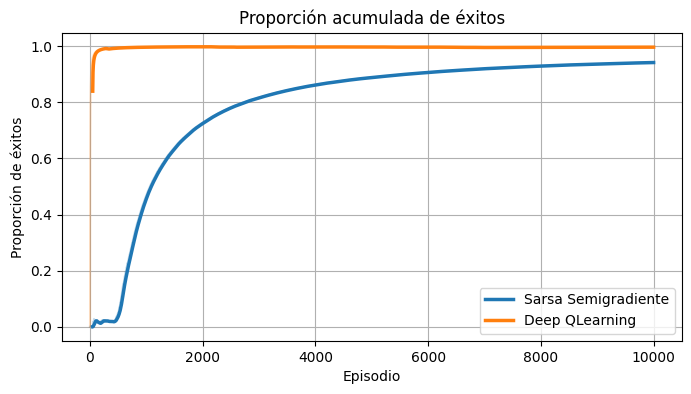

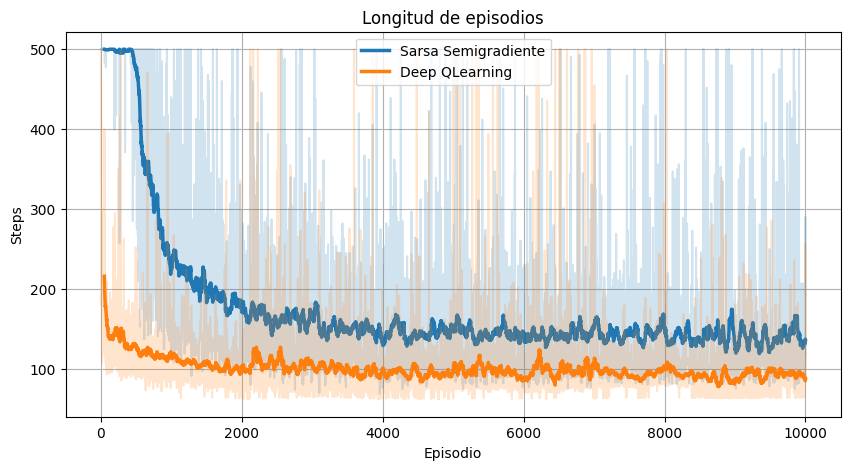

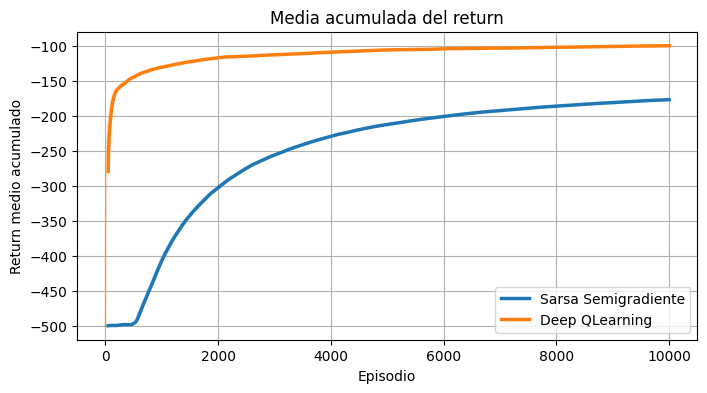

In [30]:
plot_all_results(final_results)

## Análisis de la proporción acumulada de éxitos

La primera gráfica muestra la evolución de la **proporción acumulada de episodios exitosos**, es decir, aquellos episodios en los que el agente consigue **elevar el brazo del sistema Acrobot hasta la altura objetivo**.


- **Deep Q-Learning (DQN)** alcanza tasas de éxito muy altas en un número reducido de episodios.
- **SARSA semigradiente** también mejora progresivamente su tasa de éxito, aunque lo hace de forma más lenta.
- En los primeros episodios, **SARSA semigradiente presenta una pequeña caída inicial** antes de comenzar a mejorar. Esto ocurre porque al inicio del entrenamiento el agente explora más y la aproximación mediante **tile coding** todavía no representa adecuadamente el espacio de estados. Como consecuencia, las estimaciones de los valores de acción son poco precisas y el agente tarda algunos episodios en identificar qué acciones conducen a trayectorias exitosas.
- Con suficientes episodios de entrenamiento, **ambos algoritmos terminan alcanzando proporciones de éxito cercanas a 1**, lo que indica que ambos pueden aprender una política eficaz para resolver el entorno.

### Interpretación

El comportamiento observado es coherente con las características de los algoritmos utilizados.

- **Deep Q-Learning** aprende más rápido porque utiliza una **red neuronal** para aproximar la función \(Q(s,a)\), lo que permite representar relaciones más complejas entre estados y acciones en un entorno continuo como **Acrobot-v1**.
- Además, DQN incorpora **experience replay**, que permite reutilizar experiencias pasadas y entrenar la red utilizando **mini-batches aleatorios**, lo que acelera el aprendizaje y mejora la estabilidad.
- La subida rápida de DQN al principio del entrenamiento ocurre cuando el **replay buffer** comienza a llenarse de experiencias, permitiendo que el agente entrene con múltiples transiciones pasadas y propague más rápidamente la información útil.
- En cambio, **SARSA semigradiente** utiliza **tile coding y una aproximación lineal**, lo que permite generalizar entre estados pero tiene una capacidad de representación más limitada que una red neuronal.
- La **bajada inicial en SARSA** puede explicarse porque al inicio del entrenamiento el agente explora intensamente y la representación del espacio de estados todavía no es suficientemente precisa para estimar correctamente los valores de acción.

En esta métrica, la velocidad de convergencia observada sigue aproximadamente el siguiente patrón:

$$
\text{Deep Q-Learning} > \text{SARSA Semigradiente}
$$

## Análisis de la longitud de los episodios

En la segunda gráfica podemos ver la **longitud de los episodios**, es decir, el número de pasos necesarios para completar cada episodio durante el entrenamiento de los distintos agentes.

Esta métrica permite medir **la eficiencia de la política aprendida**: cuanto **menos pasos necesita el agente para resolver la tarea**, mejor es la estrategia que ha aprendido.

En el entorno **Acrobot-v1**, cada paso produce una recompensa de **−1**, por lo que completar el episodio en menos pasos significa obtener un **return mayor (menos negativo)**.


- **Deep Q-Learning (DQN)** reduce el número de pasos necesarios para completar los episodios de forma más rápida y se estabiliza antes durante el entrenamiento.
- **SARSA semigradiente** también logra reducir la longitud de los episodios, pero lo hace de forma más gradual y con mayor variabilidad.
- En la gráfica se observan **picos ocasionales**, donde algunos episodios se alargan considerablemente durante el entrenamiento.

En general, **DQN aprende antes políticas eficientes**, mientras que **SARSA semigradiente tarda más episodios en converger hacia una estrategia estable**.

### Interpretación

Los resultados observados se pueden explicar a partir de las diferencias entre ambos métodos.

- **Deep Q-Learning** utiliza una **red neuronal** para aproximar la función \(Q(s,a)\) y emplea **experience replay**, lo que permite aprender a partir de múltiples experiencias pasadas y actualizar los valores de forma más estable. Esto facilita que el agente descubra estrategias eficientes más rápidamente y que la longitud de los episodios se estabilice antes.

- En cambio, **SARSA semigradiente** utiliza **tile coding con una aproximación lineal**, que permite generalizar entre estados similares pero tiene una capacidad de representación más limitada. Como consecuencia, el ajuste de los valores de acción puede ser más lento y producir mayor variabilidad durante el entrenamiento.

- Los **picos observados en la gráfica** se deben principalmente a la exploración mediante una política **ε-greedy**. Durante el entrenamiento el agente sigue explorando, por lo que en algunos episodios puede seleccionar acciones subóptimas que provocan trayectorias más largas.

- Además, el entorno **Acrobot-v1** presenta una **dinámica física compleja**, ya que el agente debe generar oscilaciones para acumular energía y elevar el brazo. Incluso con una buena política, el agente necesita realizar varias oscilaciones antes de alcanzar el objetivo, lo que limita la reducción del número de pasos.

## Análisis de la media acumulada del return

En la última gráfica mostramos la evolución de la **media acumulada del return** durante el entrenamiento para los dos agentes.

El return acumulado refleja el **rendimiento esperado de la política aprendida**.  
En el entorno **Acrobot-v1**, cada paso tiene una penalización de **−1**, por lo que un return **menos negativo** indica que el agente necesita **menos pasos para resolver la tarea**.

Por tanto, valores de return más altos (menos negativos) suelen indicar:

- menos pasos por episodio,
- mayor eficiencia en la política aprendida,
- mayor número de episodios resueltos correctamente.

- **Deep Q-Learning (DQN)** mejora el return medio con mayor rapidez durante el entrenamiento.
- **SARSA semigradiente** también mejora de forma progresiva, aunque su avance es más gradual.
- Ambos algoritmos terminan alcanzando valores de return relativamente estables, lo que indica que han aprendido políticas capaces de resolver el entorno.

En general, **DQN converge antes y alcanza valores de return mejores que SARSA semigradiente**.

### Interpretación

Al inicio del entrenamiento el **return tiene valores muy negativos**, ya que el agente actúa prácticamente al azar.

A medida que el agente aprende, el return mejora progresivamente porque el número de pasos necesarios para completar la tarea disminuye.

Las diferencias observadas entre los algoritmos pueden explicarse por sus características:

- **Deep Q-Learning** utiliza una **red neuronal** para aproximar la función \(Q(s,a)\) y además emplea **experience replay**, lo que permite reutilizar experiencias pasadas y aprender patrones complejos del entorno con mayor rapidez. Esto explica por qué su curva mejora antes que la de SARSA semigradiente.

- **SARSA semigradiente** utiliza **tile coding con una aproximación lineal**, lo que permite generalizar entre estados similares pero tiene una capacidad de representación más limitada que una red neuronal. Como consecuencia, el aprendizaje suele ser más lento y el progreso del return es más gradual.

- Finalmente, las curvas tienden a **estabilizarse** cuando el agente encuentra una estrategia que resuelve el problema de forma consistente. En ese momento, el número de pasos necesarios para completar los episodios se mantiene relativamente constante y el return medio deja de mejorar de forma significativa.

## Análisis de los hiperparámetros utilizados

El rendimiento de los algoritmos implementados depende en gran medida de la elección de los **hiperparámetros**, ya que estos determinan el equilibrio entre **exploración del entorno**, **velocidad de aprendizaje** y **propagación de la recompensa**.

En este experimento se han utilizado los siguientes parámetros: **ε (exploración)**, **γ (factor de descuento)** y **α (tasa de aprendizaje)**. Cada uno de ellos influye de forma diferente en el comportamiento de los algoritmos.

Además, al trabajar con métodos de aproximación de funciones aparecen otros parámetros relevantes, como la **estructura del aproximador**, el **replay buffer** o el **tamaño de los mini-batches** utilizados durante el entrenamiento.


A continuación se muestra un resumen de los hiperparámetros utilizados en los dos agentes implementados.

| Algoritmo | ε inicial | Decaimiento ε | γ (discount factor) | α (learning rate) | Otros |
|-----------|-----------|---------------|--------------------|------------------|------|
| SARSA Semigradiente | 1.0 | ε = min(1, c/(t+1)) con c = 400 | 0.99 | 0.2 | Tile coding (8 tilings, 10 bins) |
| Deep Q-Learning (DQN) | 0.4 | ε decay = 0.9995 | 1.0 | lr = 1e-3 | Replay Buffer (10000), batch = 64, target update = 100 |

- En **SARSA semigradiente**, la función \(Q\) se aproxima mediante **tile coding y una aproximación lineal**.
- En **Deep Q-Learning**, la función \(Q\) se aproxima mediante una **red neuronal**.
- El **replay buffer** permite reutilizar experiencias pasadas y mejorar la estabilidad del entrenamiento.

#### Exploración (ε)

El parámetro **ε** controla la exploración mediante una política **ε-greedy**. Con probabilidad ε el agente selecciona una acción aleatoria y con probabilidad \(1-ε\) selecciona la acción greedy.

Esto permite equilibrar **exploración y explotación**, ya que al inicio del entrenamiento el agente explora diferentes trayectorias del entorno y, conforme ε disminuye, comienza a explotar la política aprendida.

En **SARSA semigradiente**, el valor inicial de ε es alto para favorecer la exploración del espacio continuo. Posteriormente se aplica un **decaimiento progresivo controlado por el parámetro \(c\)**, lo que permite que la política se vuelva cada vez más greedy conforme el agente adquiere experiencia.

En **Deep Q-Learning**, el agente comienza con un valor moderado de ε y se aplica un **decaimiento exponencial**, lo que permite mantener exploración durante gran parte del entrenamiento sin impedir la convergencia hacia una política eficiente.

#### Factor de descuento (γ)

El parámetro **γ** determina la importancia de las recompensas futuras en el cálculo del retorno:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$$

Valores de γ cercanos a **1** hacen que el agente tenga en cuenta recompensas a largo plazo, mientras que valores más pequeños priorizan recompensas inmediatas.

En el entorno **Acrobot-v1**, el objetivo se alcanza después de una secuencia relativamente larga de acciones necesarias para generar las oscilaciones que permiten elevar el brazo. Por este motivo se utilizan valores de **γ cercanos a 1**, lo que facilita que la recompensa final se propague hacia los estados anteriores y permita aprender trayectorias eficientes.

#### Tasa de aprendizaje (α)

La tasa de aprendizaje **α** controla cuánto se ajustan las estimaciones de valor en cada actualización.

En los algoritmos de diferencias temporales, las actualizaciones siguen la forma general:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha [\text{target} - Q(s,a)]
$$

Este parámetro determina cuánto influye la nueva información observada sobre la estimación actual.

- Valores **altos** pueden provocar aprendizaje inestable.
- Valores **bajos** producen un aprendizaje más lento.

En **SARSA semigradiente** se utiliza **α = 0.2**, lo que permite que el agente ajuste los pesos de la aproximación lineal de forma relativamente rápida sin introducir demasiada inestabilidad.

En **Deep Q-Learning**, el equivalente a la tasa de aprendizaje es el **learning rate de la red neuronal**, que en este caso se ha fijado en **\(10^{-3}\)**, un valor que permite entrenar la red de forma estable.

#### Aproximación de la función de valor

Una diferencia importante entre ambos métodos está en la forma en que se aproxima la función \(Q\).

En **SARSA semigradiente**, la aproximación se realiza mediante **tile coding y una función lineal**, lo que permite generalizar entre estados similares pero tiene una capacidad de representación limitada.

En **Deep Q-Learning**, la función \(Q\) se aproxima mediante una **red neuronal profunda** con la siguiente estructura:

input → 12 → 8 → num\_actions

Las capas utilizan activaciones **ReLU** y los pesos se inicializan mediante **Kaiming initialization**, lo que mejora la estabilidad del entrenamiento.

### Conclusión

La combinación de estos hiperparámetros permite lograr un equilibrio adecuado entre **exploración inicial del entorno** y **convergencia hacia una política eficiente** en el entorno **Acrobot-v1**.

- Un **ε relativamente alto al inicio** favorece la exploración del espacio de estados.
- El **decaimiento de ε** permite que el agente se vuelva progresivamente más greedy.
- Un **γ cercano a 1** facilita aprender trayectorias largas necesarias para resolver el entorno.
- Una **tasa de aprendizaje moderada** permite actualizar las estimaciones sin introducir demasiada inestabilidad.

En conjunto, estos parámetros permiten que ambos métodos aprendan políticas efectivas, aunque **Deep Q-Learning converge más rápido gracias a su mayor capacidad de representación** en el entorno de Acrobot.

In [31]:
# Graba un vídeo de 1 episodio mostrando el comportamiento del agente en Acrobot segun el agente implementado
def record_agent_acrobot(agent, name_prefix: str, filepath: str = "./video_acrobot",
                         env_id: str = "Acrobot-v1", seed: int = 42, max_steps: int = 500):
 
    Path(filepath).mkdir(parents=True, exist_ok=True)

    # Entorno con render RGB
    env_video = gym.make(env_id, render_mode="rgb_array")
    env_video.reset(seed=seed)

    # Wrapper para grabar vídeo
    env_video = RecordVideo(
        env_video,
        video_folder=filepath,
        name_prefix=name_prefix,
        episode_trigger=lambda e: True, 
        disable_logger=True
    )

    # Evaluación sin exploración
    old_eps = getattr(agent, "epsilon", None)
    if old_eps is not None:
        agent.epsilon = 0.0

    state, _ = env_video.reset(seed=seed)
    total_reward = 0.0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:

        if hasattr(agent, "get_greedy_action"):
            action = agent.get_greedy_action(state)  
        else:
            action = agent.get_action(state)         

        state, reward, terminated, truncated, _ = env_video.step(action)
        total_reward += reward
        steps += 1

    env_video.close()

    if old_eps is not None:
        agent.epsilon = old_eps

    print(f"Vídeo guardado en: {filepath}")

    mp4s = sorted(Path(filepath).glob(f"{name_prefix}*.mp4"),
                  key=lambda p: p.stat().st_mtime, reverse=True)

    if len(mp4s) > 0:
        display(Video(str(mp4s[0]), embed=True, width=520))
    else:
        print("No se encontró el vídeo. Revisa el wrapper RecordVideo y permisos de escritura.")



# SARSA semigradiente 
print("Ejecucion de Sarsa Semigradiente")
record_agent_acrobot(agentSarsaSemigrad, name_prefix="acrobot-sarsa-semi-gradiente", filepath="./video_acrobot", seed=seed)

# Deep Q-Learning
print("Ejecucion de Deep QLearning")

record_agent_acrobot(agentDeepQLearning, name_prefix="acrobot-dqn", filepath="./video_acrobot", seed=seed)


Ejecucion de Sarsa Semigradiente
Vídeo guardado en: ./video_acrobot


Ejecucion de Deep QLearning
Vídeo guardado en: ./video_acrobot


## Conclusión final

En este notebook se han comparado dos métodos de **aprendizaje por refuerzo con aproximación de funciones**:  
**SARSA semigradiente** y **Deep Q-Learning (DQN)**, utilizando el entorno **Acrobot-v1**.

A partir del análisis de las tres métricas estudiadas: **proporción acumulada de éxitos**, **longitud de los episodios** y **media acumulada del return** se observan diferencias claras en la velocidad de aprendizaje y la estabilidad de los algoritmos.

Los resultados muestran que **Deep Q-Learning** aprende estrategias eficaces con mayor rapidez. Este método alcanza tasas de éxito altas en menos episodios, reduce antes la longitud de los episodios y obtiene valores de return menos negativos. Este comportamiento es coherente con la teoría, ya que DQN utiliza una **red neuronal** para aproximar la función \(Q(s,a)\), lo que le permite representar relaciones más complejas entre estados y acciones en un entorno continuo como **Acrobot-v1**.

Además, el uso de **experience replay** permite reutilizar experiencias pasadas y entrenar la red con **mini-batches de transiciones**, lo que acelera la propagación de la información útil y mejora la estabilidad del aprendizaje.

Por su parte, **SARSA semigradiente** también converge hacia una política capaz de resolver el entorno, aunque lo hace de forma más gradual. Este método utiliza **tile coding y una aproximación lineal**, lo que permite generalizar entre estados similares pero tiene una capacidad de representación más limitada que una red neuronal. Como consecuencia, el proceso de aprendizaje suele ser más lento y presenta mayor variabilidad durante el entrenamiento.

El análisis de la longitud de los episodios muestra además que, a medida que los agentes aprenden estrategias más eficientes, el número de pasos necesarios para resolver el entorno disminuye y las curvas tienden a estabilizarse. Esto indica que los agentes han encontrado políticas que resuelven el problema de forma consistente.

Además del análisis cuantitativo, al final del notebook se incluyen **vídeos de evaluación de los agentes entrenados**. En ellos se ejecuta un episodio utilizando la política aprendida por cada algoritmo, lo que permite observar de forma cualitativa cómo los agentes aplican la estrategia aprendida para generar las oscilaciones necesarias y elevar el brazo del sistema **Acrobot** hasta la altura objetivo.

En conjunto, los resultados obtenidos coinciden con lo esperado teóricamente: los métodos basados en **aproximación de funciones mediante redes neuronales**, como **Deep Q-Learning**, resultan especialmente eficaces cuando el espacio de estados es **continuo o muy grande**, como ocurre en el entorno **Acrobot-v1**.